# Theory intuition

 > A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. However, there are some parameters, known as Hyperparameters and those cannot be directly learned. They are commonly chosen by humans based on some intuition or hit and trial before the actual training begins. These parameters exhibit their importance by improving the performance of the model such as its complexity or its learning rate. Models can have many hyper-parameters and finding the best combination of parameters can be treated as a search problem

 > Gridsearch is a simple concept but effective technique in Machine Learning. The word GridSearch stands for the fact that we are searching for optimal parameter/parameters over a "grid." These optimal parameters are also known as Hyperparameters. The Hyperparameters are model parameters that are set before fitting the model and determine the behavior of the model. For example, when we choose to use linear regression, we may decide to add a penalty to the loss function such as Ridge or Lasso. These penalties require specific alpha (the strength of the regularization technique) to set beforehand. The higher the value of alpha, the more penalty is being added. GridSearch finds the optimal value of alpha among a range of values provided by us, and then we go on and use that optimal value to fit the model and get sweet results. It is essential to understand those model parameters are different from models outcomes, for example, **coefficients** or model evaluation metrics such as **accuracy score** or **mean squared error** are model outcomes and different than hyperparameters.

# import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
from sklearn.metrics._plot.precision_recall_curve import precision_recall_curve
from sklearn.model_selection import GridSearchCV,StratifiedKFold

from sklearn.preprocessing import OrdinalEncoder ,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,precision_score,recall_score,accuracy_score,confusion_matrix

In [3]:
loan = pd.read_csv("/content/sample_data/train_u6lujuX_CVtuZ9i.csv")
loan = loan.drop("Loan_ID", axis=1)

In [4]:
loan.head().style.set_properties(**{'background-color' : 'white',
                           'color' : 'Blue',
                           'border-color' : 'Blue',
                           'font-size':'15px','font-family' :'Times Roman New'})

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.000000,nan,360.000000,1.000000,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.000000,128.000000,360.000000,1.000000,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.000000,66.000000,360.000000,1.000000,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.000000,120.000000,360.000000,1.000000,Urban,Y
4,Male,No,0,Graduate,No,6000,0.000000,141.000000,360.000000,1.000000,Urban,Y


# Handling missing value

In [5]:
loan.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
loan["Gender"].fillna(method="backfill",inplace=True)
loan["Married"].fillna(value="Yes",inplace=True)
loan["Dependents"].fillna(value= 0,inplace=True)
loan['Self_Employed'].fillna('No', inplace=True)
loan['LoanAmount'].fillna(loan['LoanAmount'].mean(), inplace=True)
loan['Loan_Amount_Term'].fillna(value= 360,inplace=True)
loan['Credit_History'].fillna(method="backfill", inplace=True)

In [8]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [9]:
loan.nunique()

,0
Gender,2
Married,2
Dependents,5
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,204
Loan_Amount_Term,10
Credit_History,2


# Encoding

In [10]:
# --- 1. Define explicit orders for true ordinal columns ---
# Make sure these match the exact spelling and casing in your dataframe
dependents_order = ['0', '1', '2', '3+']
education_order = ['Not Graduate', 'Graduate']
property_order = ['Rural', 'Semiurban', 'Urban']

# For nominal columns, scikit-learn can determine the order automatically (alphabetical)
gender_order = ['Female', 'Male']
married_order = ['No', 'Yes']
self_emp_order = ['No', 'Yes']

# --- 2. Combine into a master category list ---
# Note: The order of this list must perfectly match the columns selected in step 4
ordered_categories = [
    gender_order,
    married_order,
    dependents_order,
    education_order,
    self_emp_order,
    property_order
]

# --- 3. Initialize the Encoder ---
# We include 'handle_unknown' just in case new text values show up later
encoder = OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1)

# --- 4. Select features and Transform ---
feature_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Transform and overwrite the original columns (or create new ones if you prefer)
loan[feature_cols] = encoder.fit_transform(loan[feature_cols])

# --- 5. Handle the Target Column (Loan_Status) ---
# Target variables should use LabelEncoder instead of OrdinalEncoder
le = LabelEncoder()
loan['Loan_Status'] = le.fit_transform(loan['Loan_Status'])

In [11]:
loan.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1.0,0.0,0.0,1.0,0.0,5849,0.0,146.412162,360.0,1.0,2.0,1
1,1.0,1.0,1.0,1.0,0.0,4583,1508.0,128.000000,360.0,1.0,0.0,0
2,1.0,1.0,0.0,1.0,1.0,3000,0.0,66.000000,360.0,1.0,2.0,1


# Split the dataset

In [12]:
X = loan.drop('Loan_Status', axis=1)
y = loan['Loan_Status']

In [13]:
X_train, X_test, y_train,y_test = train_test_split(
                                                         X,y,
                                                         test_size=.20,
                                                         random_state= 42

)

In [14]:
X_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
83,1.0,1.0,0.0,1.0,0.0,6000,2250.0,265.0,360.0,1.0,1.0
90,1.0,1.0,0.0,1.0,0.0,2958,2900.0,131.0,360.0,1.0,1.0


# Model Building

## Logistic Regression

Training Accuracy    : 80.45 %
Model Accuracy Score : 79.67 %
--------------------------------------------------------


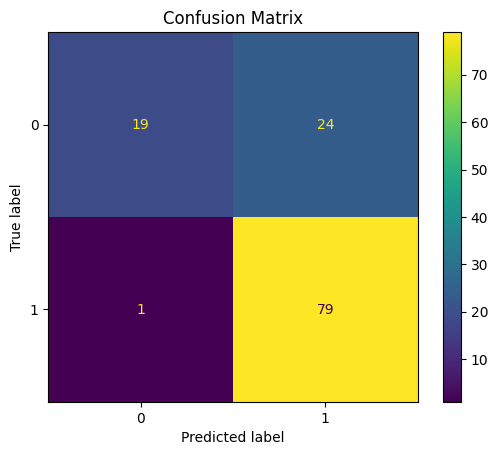

In [15]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
# 1. Swap plot_confusion_matrix with ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

log_train = round(logreg.score(X_train, y_train) * 100, 2)
log_accuracy = round(accuracy_score(y_pred_lr, y_test) * 100, 2)

print("Training Accuracy    :", log_train, "%")
print("Model Accuracy Score :", log_accuracy, "%")
print("\033[1m--------------------------------------------------------\033[0m")

# 2. Use the new syntax to plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
plt.title('Confusion Matrix')
plt.show() # Ensures the plot renders cleanly in notebook

## GridSearchCV

In [20]:
C_Values = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

penalties = ['l1','l2']

param = {
    'penalty': penalties,
    'C' : C_Values
    }

LogRegression = LogisticRegression()

grid_logistic = GridSearchCV (estimator = LogisticRegression(),
                         param_grid = param,
                         scoring = 'accuracy',
                         cv=5

                         )
grid_logistic.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                               15, 16, 17],
                         'penalty': ['l1', 'l2']},
             scoring='accuracy')

## Best Score

In [21]:
print(grid_logistic.best_score_)

print(grid_logistic.best_params_)

print(grid_logistic.best_estimator_)



0.8023912595341167
{'C': 9, 'penalty': 'l2'}
LogisticRegression(C=9)


 > WE found the best parameters.

## Train with best params

Training Accuracy with GridSearch : 80.45 %
Testing Accuracy with GridSearch  : 79.67 %
------------------------------------------------------------


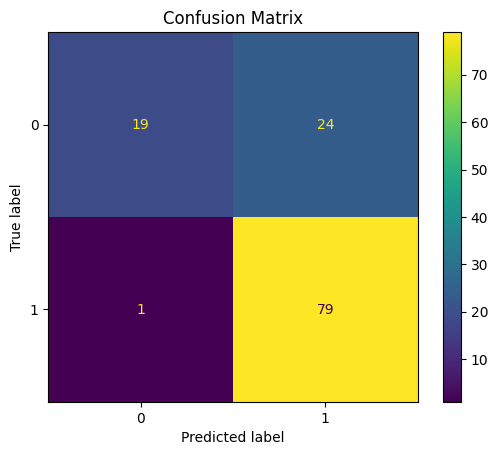

In [27]:
logistic_grid = grid_logistic.best_estimator_

log_train_grid = round(logistic_grid.score(X_train, y_train) * 100, 2)
log_accuracy_grid = round(logistic_grid.score(X_test, y_test) * 100, 2)

print("Training Accuracy with GridSearch :", log_train_grid, "%")
print("Testing Accuracy with GridSearch  :", log_accuracy_grid, "%")

print("-" * 60)

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

## findings

GridSearchCV answered the question:

 > "Among the parameter values you gave me, which one performs best during cross-validation?"

 > GridSearchCV was applied to tune the Logistic Regression model using 5-fold cross-validation. The best hyperparameters found were C = 9 and penalty = 'l2', achieving an average cross-validation accuracy of 80.24%. After retraining the model with these hyperparameters, the training accuracy remained 80.45% and the testing accuracy remained 79.67%, indicating that hyperparameter tuning did not improve performance over the default Logistic Regression model. This suggests that the default settings were already close to optimal for the given dataset, and the model's performance is relatively insensitive to the tested values of C.

In [28]:
logistic_grid = grid_logistic.best_estimator_

y_pred = logistic_grid.predict(X_test)


In [29]:
print("Training Accuracy :", round(logistic_grid.score(X_train,y_train)*100,2), "%")
print("Testing Accuracy  :", round(accuracy_score(y_test,y_pred)*100,2), "%")

Training Accuracy : 80.45 %
Testing Accuracy  : 79.67 %


# Test Dataset - > Test the model

> Now we will test the model with another test dataset

In [49]:
loan_test = pd.read_csv('/content/sample_data/test_Y3wMUE5_7gLdaTN.csv')

loan_test.head(4)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban


In [50]:
loan_test = loan_test.drop(['Loan_ID'],axis=1)
loan_test.head(4)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban


## missing value

In [51]:
loan_test.isnull().sum()

,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6
Credit_History,29


In [52]:
loan_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             356 non-null    object 
 1   Married            367 non-null    object 
 2   Dependents         357 non-null    object 
 3   Education          367 non-null    object 
 4   Self_Employed      344 non-null    object 
 5   ApplicantIncome    367 non-null    int64  
 6   CoapplicantIncome  367 non-null    int64  
 7   LoanAmount         362 non-null    float64
 8   Loan_Amount_Term   361 non-null    float64
 9   Credit_History     338 non-null    float64
 10  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 31.7+ KB


In [53]:
loan['Self_Employed'].fillna('No', inplace=True)
loan["Gender"].fillna(method="backfill",inplace=True)
loan_test['LoanAmount'].fillna(loan['LoanAmount'].mean(), inplace=True)
loan_test['Loan_Amount_Term'].fillna(value= 360,inplace=True)
loan_test['Credit_History'].fillna(method="backfill", inplace=True)

In [54]:
# --- 1. Define explicit orders for true ordinal columns ---
# Make sure these match the exact spelling and casing in your dataframe
dependents_order = ['0', '1', '2', '3+']
education_order = ['Not Graduate', 'Graduate']
property_order = ['Rural', 'Semiurban', 'Urban']

# For nominal columns, scikit-learn can determine the order automatically (alphabetical)
gender_order = ['Female', 'Male']
married_order = ['No', 'Yes']
self_emp_order = ['No', 'Yes']

# --- 2. Combine into a master category list ---
# Note: The order of this list must perfectly match the columns selected in step 4
ordered_categories = [
    gender_order,
    married_order,
    dependents_order,
    education_order,
    self_emp_order,
    property_order
]

# --- 3. Initialize the Encoder ---
# We include 'handle_unknown' just in case new text values show up later
encoder = OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1)

# --- 4. Select features and Transform ---
feature_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Transform and overwrite the original columns (or create new ones if you prefer)
loan_test[feature_cols] = encoder.fit_transform(loan_test[feature_cols])

In [35]:
loan_test.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1.0,1.0,0.0,1.0,0.0,5720,0,110.0,360.0,1.0,2.0
1,1.0,1.0,1.0,1.0,0.0,3076,1500,126.0,360.0,1.0,2.0
2,1.0,1.0,2.0,1.0,0.0,5000,1800,208.0,360.0,1.0,2.0


## predict

In [55]:
predictions = logistic_grid.predict(loan_test)
print(predictions)

[1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1
 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0
 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 0 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]
